In [ ]:
import numpy as np
import pandas as pd
from conda.core.initialize import initialize
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,log_loss
import matplotlib.pyplot as plt
import seaborn as sns

from day_02_machine_learning.test import y_pred

In [117]:
# loading dataset
hr_df=pd.read_csv("../Datasets/HR_comma_sep.csv")
hr_df.shape
print(hr_df.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.10             0.77               6                   247   
3                0.92             0.85               5                   259   
4                0.89             1.00               5                   224   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   5              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

In [118]:
# Soruce feature and source
X=hr_df["satisfaction_level"]
Y=hr_df["left"]

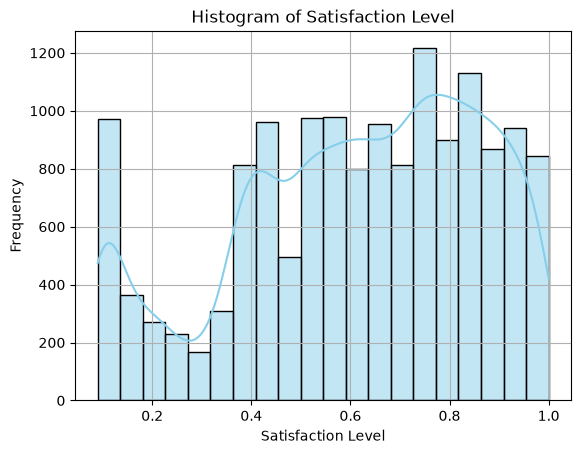

In [119]:
plt.Figure(figsize=(8,6))
sns.histplot(data=X,bins=20,color='skyblue',kde=True)
plt.title("Histogram of Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

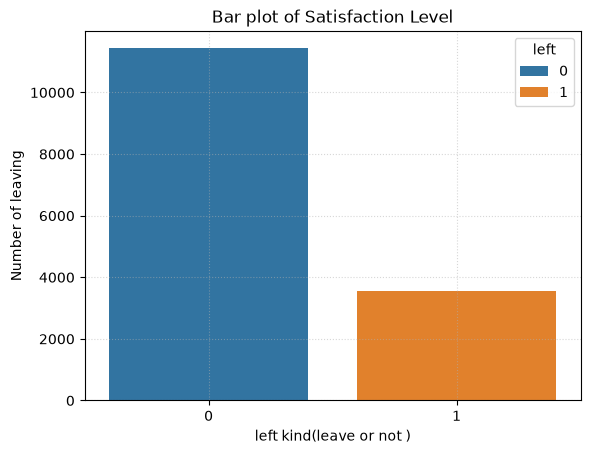

In [120]:
counts=hr_df["left"].value_counts()
sns.barplot(x=counts.index,y=counts.values,color="skyblue",palette=["#1f77b4", "#ff7f0e"],hue=counts.index)
plt.title("Bar plot of Satisfaction Level")
plt.xlabel("left kind(leave or not )")
plt.ylabel("Number of leaving")
plt.grid(True,linestyle=":",alpha=0.5)
plt.show()

In [121]:
# intiailize paramters
eta=0.4
epoch=10000
w=0.1
b=0.1


In [122]:
# sigmod function
def sigmoid(z):
    return 1/(1+np.exp(-z))

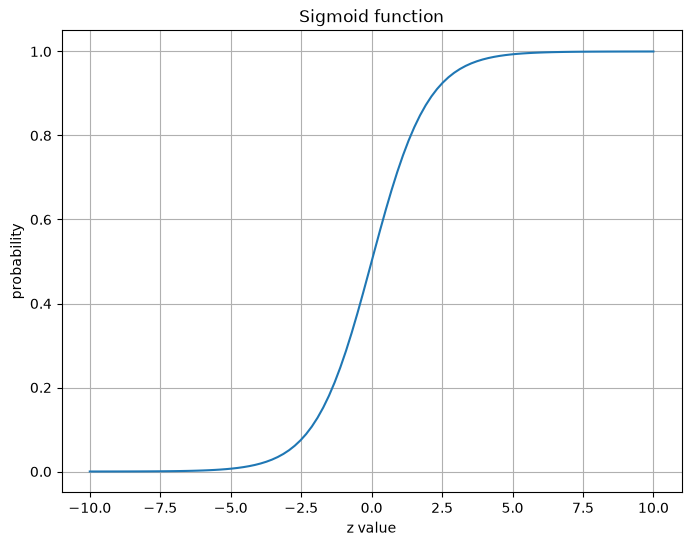

In [123]:
z=np.linspace(-10,10,100)
plt.figure(figsize=(8,6))
plt.plot(z,sigmoid(z),label="sigmoid")
plt.title("Sigmoid function")
plt.xlabel("z value")
plt.ylabel("probability")
plt.grid(True)
plt.show()

In [124]:
# prediction
# initial prediction
y_curve=sigmoid(w*(X+b))
print(y_curve[:10])

0    0.511998
1    0.522485
2    0.505000
3    0.525478
4    0.524730
5    0.512997
6    0.513747
7    0.505250
8    0.523483
9    0.512747
Name: satisfaction_level, dtype: float64


In [125]:
# loss function error prediction
L1=log_loss(Y,y_curve)
print(L1)

0.7166551405833022


In [126]:
# Define Grdaient
dw=-np.mean((Y-y_curve)*X)

dv=-np.mean((Y-y_curve))
# bais
print(dw)
print(dv)

0.2142047440687472
0.2799328068674543


In [127]:
import numpy as np

loss_history = []
weight_history = []
bias_history = []

for i in range(epoch):
    z = w * X + b
    y_pred = sigmoid(z)

    l1 = log_loss(Y, y_pred)

    loss_history.append(l1)
    weight_history.append(w)
    bias_history.append(b)


    if i % 100 == 0:
        print(f"epoch={i} , loss = {l1:.3f} , weight={w:.3f} , bias={b:.3f}")


    dw = np.mean((y_pred - Y) * X)
    db = np.mean(y_pred - Y)


    w = w - eta * dw
    b = b - eta * db

epoch=0 , loss = 0.743 , weight=0.100 , bias=0.100
epoch=100 , loss = 0.502 , weight=-1.420 , bias=-0.390
epoch=200 , loss = 0.488 , weight=-2.055 , bias=-0.016
epoch=300 , loss = 0.481 , weight=-2.516 , bias=0.248
epoch=400 , loss = 0.478 , weight=-2.852 , bias=0.437
epoch=500 , loss = 0.476 , weight=-3.099 , bias=0.574
epoch=600 , loss = 0.475 , weight=-3.282 , bias=0.674
epoch=700 , loss = 0.474 , weight=-3.418 , bias=0.749
epoch=800 , loss = 0.474 , weight=-3.520 , bias=0.804
epoch=900 , loss = 0.473 , weight=-3.596 , bias=0.845
epoch=1000 , loss = 0.473 , weight=-3.653 , bias=0.876
epoch=1100 , loss = 0.473 , weight=-3.697 , bias=0.900
epoch=1200 , loss = 0.473 , weight=-3.729 , bias=0.917
epoch=1300 , loss = 0.473 , weight=-3.754 , bias=0.931
epoch=1400 , loss = 0.473 , weight=-3.773 , bias=0.941
epoch=1500 , loss = 0.473 , weight=-3.787 , bias=0.948
epoch=1600 , loss = 0.473 , weight=-3.798 , bias=0.954
epoch=1700 , loss = 0.473 , weight=-3.806 , bias=0.959
epoch=1800 , loss = 0

In [135]:
print("Final Weight",weight_history[-1])
print("Final Bias",bias_history[-1])

Final Weight -3.8315448363112847
Final Bias 0.9723239781418312


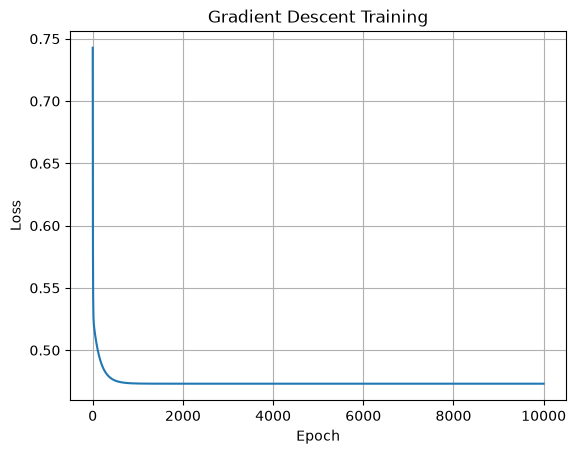

In [128]:
plt.Figure(figsize=(8,6))
plt.plot(loss_history,label="Training Loss")
plt.title("Gradient Descent Training")
plt.xlabel("Etoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

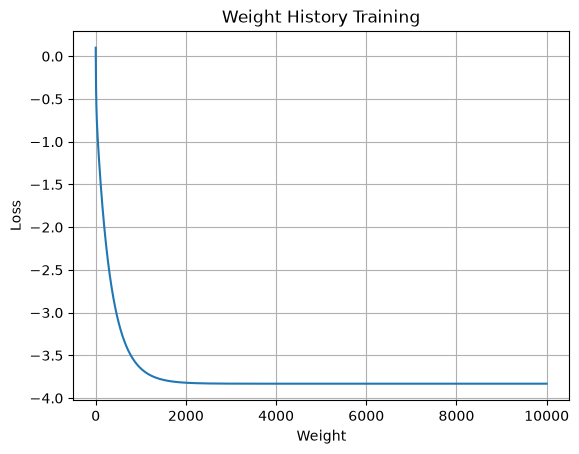

In [129]:
plt.Figure(figsize=(7,4))
plt.plot(weight_history,label="Weight History")
plt.title("Weight History Training")
plt.xlabel("Weight")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

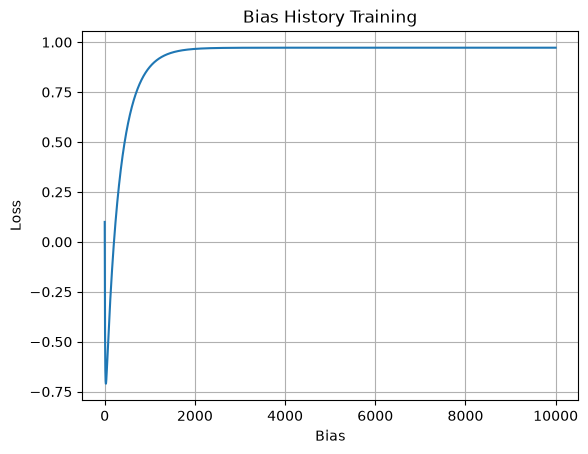

In [130]:
plt.Figure(figsize=(7,4))
plt.plot(bias_history,label="Bias History")
plt.title("Bias History Training")
plt.xlabel("Bias")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
# Gradient upated
# new weight=old weight-learning_rate*gradient (the same)

In [131]:
# model train and view how reducing and e-to
probability=sigmoid(w*X+b)
prediction=(probability>=0.5).astype(int)
acc=accuracy_score(Y,prediction)
print(acc)

0.7683894631543848


<Axes: >

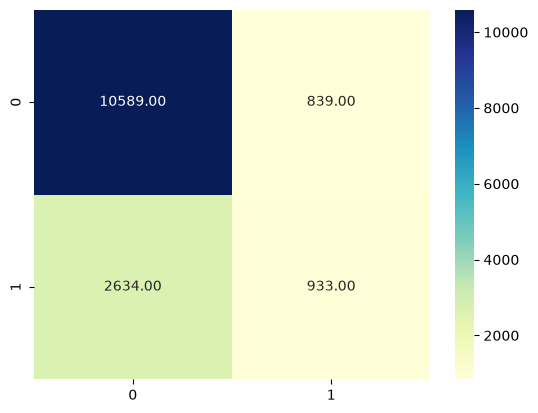

In [132]:
sns.heatmap(confusion_matrix(Y,prediction), annot=True, cmap="YlGnBu", fmt=".2f")

In [133]:
# evaluation metrics
print(confusion_matrix(Y,prediction))

[[10589   839]
 [ 2634   933]]


In [134]:
print(classification_report(Y,prediction))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86     11428
           1       0.53      0.26      0.35      3567

    accuracy                           0.77     14995
   macro avg       0.66      0.59      0.60     14995
weighted avg       0.74      0.77      0.74     14995



In [ ]:
from sklearn.preprocessing import StandardScaler

In [104]:
scaler=StandardScaler()
df=pd.read_csv("../Datasets/HR_comma_sep.csv")

In [105]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [106]:
x=df[["satisfaction_level","number_project"]].values
y=df["left"].values

In [ ]:
scaler_x=scaler.fit_transform(x)

In [107]:
x1=scaler_x[:,0]
x2=scaler_x[:,1]

In [108]:
eta=0.4
epoch=10000
w1=0.1
w2=0.1
b=0.1

In [109]:
loss_history = []
w1_history = []
w2_history = []
bias_history = []

for i in range(epoch):
    # Linear combination
    z = w1 * x1 + w2 * x2 + b

    # Sigmoid prediction
    y_pred = sigmoid(z)

    # Loss
    l1 = log_loss(y, y_pred)

    # Store history
    loss_history.append(l1)
    w1_history.append(w1)
    w2_history.append(w2)
    bias_history.append(b)

    # Print every 100 epochs
    if i % 100 == 0:
        print(f"Epoch={i}, Loss={l1:.3f}, W1={w1:.3f}, W2={w2:.3f}, Bias={b:.3f}")

        # Gradients
        dw1 = np.mean((y_pred - Y) * x1)
        dw2 = np.mean((y_pred - Y) * x2)
        db = np.mean(y_pred - Y)

        # Update parameters
        w1 = w1 - eta * dw1
        w2 = w2 - eta * dw2
        b = b - eta * db



Epoch=0, Loss=0.738, W1=0.100, W2=0.100, Bias=0.100
Epoch=100, Loss=0.694, W1=0.025, W2=0.096, Bias=-0.015
Epoch=200, Loss=0.657, W1=-0.042, W2=0.090, Bias=-0.118
Epoch=300, Loss=0.628, W1=-0.103, W2=0.085, Bias=-0.211
Epoch=400, Loss=0.604, W1=-0.157, W2=0.079, Bias=-0.295
Epoch=500, Loss=0.584, W1=-0.207, W2=0.073, Bias=-0.371
Epoch=600, Loss=0.568, W1=-0.252, W2=0.067, Bias=-0.439
Epoch=700, Loss=0.555, W1=-0.293, W2=0.061, Bias=-0.502
Epoch=800, Loss=0.544, W1=-0.331, W2=0.055, Bias=-0.558
Epoch=900, Loss=0.534, W1=-0.365, W2=0.049, Bias=-0.610
Epoch=1000, Loss=0.527, W1=-0.397, W2=0.043, Bias=-0.657
Epoch=1100, Loss=0.520, W1=-0.427, W2=0.037, Bias=-0.701
Epoch=1200, Loss=0.514, W1=-0.454, W2=0.032, Bias=-0.741
Epoch=1300, Loss=0.509, W1=-0.480, W2=0.026, Bias=-0.777
Epoch=1400, Loss=0.505, W1=-0.504, W2=0.021, Bias=-0.811
Epoch=1500, Loss=0.501, W1=-0.526, W2=0.016, Bias=-0.843
Epoch=1600, Loss=0.498, W1=-0.547, W2=0.011, Bias=-0.872
Epoch=1700, Loss=0.495, W1=-0.567, W2=0.006, B

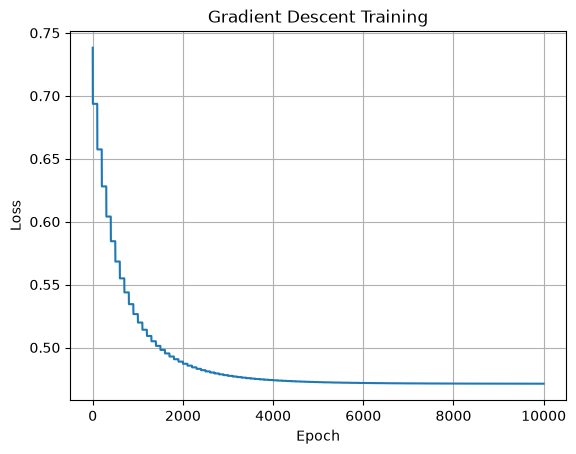

In [110]:
plt.Figure(figsize=(8,6))
plt.plot(loss_history,label="Training Loss")
plt.title("Gradient Descent Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

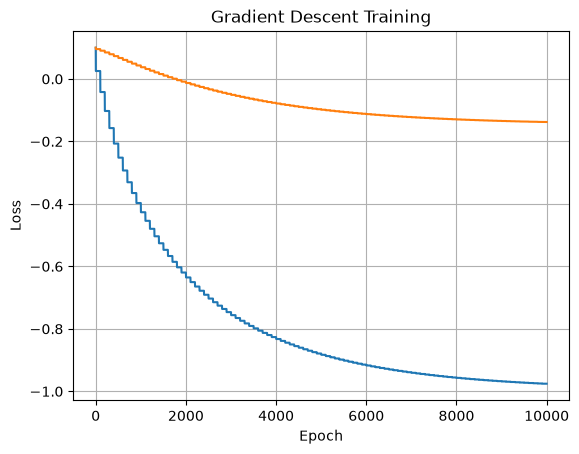

In [111]:
plt.Figure(figsize=(8,6))
plt.plot(w1_history,label="Training Loss")
plt.plot(w2_history,label="Training Loss")
plt.title("Weight Training loss")
plt.xlabel("Weight")
plt.ylabel("Feequeccy")
plt.grid(True)
plt.show()

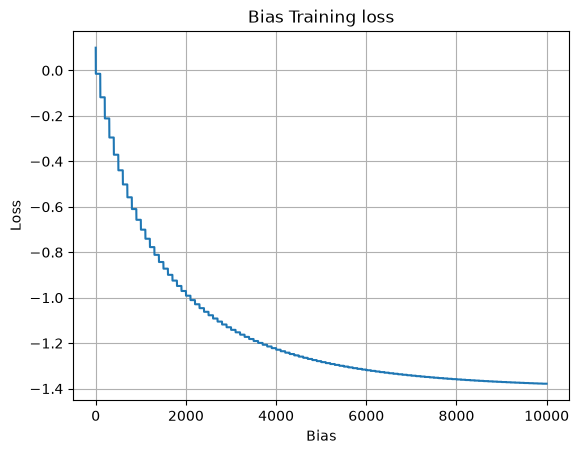

In [112]:
plt.Figure(figsize=(8,6))
plt.plot(bias_history,label="Bias Loss")
plt.title("Bias Training loss")
plt.xlabel("Bias")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [113]:
probability=sigmoid( w1 * x1 + w2 * x2 + b)
prediction=(probability>=0.5).astype(int)
acc=accuracy_score(Y,prediction)
print(acc)

0.7737912637545848


In [114]:
print(confusion_matrix(Y,prediction))

[[10675   753]
 [ 2639   928]]


<Axes: >

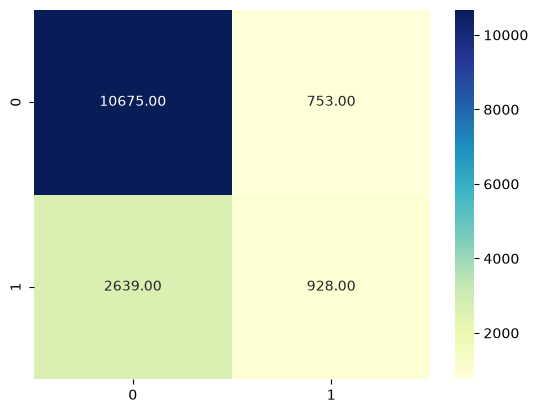

In [115]:
sns.heatmap(confusion_matrix(Y,prediction), annot=True, cmap="YlGnBu", fmt=".2f")

In [116]:
print(classification_report(Y,prediction))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86     11428
           1       0.55      0.26      0.35      3567

    accuracy                           0.77     14995
   macro avg       0.68      0.60      0.61     14995
weighted avg       0.74      0.77      0.74     14995

